# b2metric Case Study
Bora Boyacıoğlu, boraboyacioglu@icloud.com

In [ ]:
# I used a virtual environment for this notebook.
#% python3 -m venv .venv
#% source .venv/bin/activate

%pip install -q --upgrade pip
%pip install -q jupyter ipykernel pandas scikit-learn catboost lofo-importance

# My own library just for coloured outputs.
%pip install -q AnsiLib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import necessary libraries.

In [24]:
import warnings

import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import RidgeClassifier

from catboost import CatBoostClassifier

from lofo import LOFOImportance, Dataset, plot_importance

import AnsiLib as al

In [3]:
RANDOM_STATE = 17

## 1. Data Loading and Preprocessing

In [4]:
# Load the main dataset.
df = pd.read_csv('data/application_train.csv')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.

In [5]:
# Split the dataset into features and target variable.
X = df.drop(columns=['TARGET'])
y = df['TARGET']
del df

In [6]:
# List missing values.
al.prints(f'dtype(s): {set(X.dtypes)}', s=['g'])
pd.DataFrame([
    {
        'name': col,
        'dtype': X[col].dtype,
        'missing': X[col].isnull().sum()
    }
    for col in X.columns
]).sort_values(by=['dtype', 'missing'], ascending=[True, False])

dtype(s): {dtype('float64'), dtype('O'), dtype('int64')}


,name,dtype,missing
0,SK_ID_CURR,int64,0
5,CNT_CHILDREN,int64,0
16,DAYS_BIRTH,int64,0
17,DAYS_EMPLOYED,int64,0
19,DAYS_ID_PUBLISH,int64,0
...,...,...,...
12,NAME_EDUCATION_TYPE,object,0
13,NAME_FAMILY_STATUS,object,0
14,NAME_HOUSING_TYPE,object,0
31,WEEKDAY_APPR_PROCESS_START,object,0


Fill missing values

In [ ]:
for col in X.columns:  # I just learned "inplace: True" is getting deprecated.
    if X[col].dtype == 'object':
        # Fill categorical columns with unknown.
        X[col] = X[col].fillna('Unknown')
    else:
        # Fill numerical columns with median.
        X[col] = X[col].fillna(X[col].median())


## 2. Validation Strategy

**I choose: Stratified K-Fold. Why?**

Since this is a task of binary classification, and the target value is imbalanced ($91.93\%$), I prefered Stratified K-Fold. Stratified K-Fold makes sure each fold maintains the same proportion of classes as the overall dataset. This prevents biased training set and provides a more reliable evaluation of model performance.

In [ ]:
yc = y.value_counts()
print(yc)
al.prints(f'{yc[0] / (yc[0] + yc[1]) * 100:.2f}% of the data is 0', s=['y'])

TARGET
0    282686
1     24825
Name: count, dtype: int64
91.93% of the data is 0


In [9]:
# Using Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Initial Modelling

In [10]:
X.columns

Index(['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=121)

### 3.1. CatBoost Model

In [11]:
# CatBoost scores.
s_catboost = []

# Categorical columns.
cat_features = X.select_dtypes(include=['object'])\
    .columns.tolist()

for i, (i_train, i_val) in enumerate(kf.split(X, y)):
    print(f'\rFold {i + 1} of {kf.n_splits}', end='')  # type: ignore
    
    # Split the data into training and validation sets.
    X_train, X_val = X.iloc[i_train], X.iloc[i_val]
    y_train, y_val = y.iloc[i_train], y.iloc[i_val]
    
    # Train the CatBoost model.
    model = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
    model.fit(X_train, y_train, cat_features=cat_features)
    
    # Make predictions and calculate the ROC-AUC score.
    preds = model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, preds)
    s_catboost.append(score)

al.prints(f"\nCatBoost average ROC-AUC: {sum(s_catboost) / len(s_catboost):.4f}", s=['g'])

Fold 5 of 5
CatBoost average ROC-AUC: 0.7593


### 3.2. Ridge Model

In [12]:
# Numerical input for Ridge model.
X_encoded = pd.get_dummies(X)

In [13]:
s_ridge = []

# Surpress warnings.
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(divide='ignore', over='ignore', invalid='ignore')

for i, (i_train, i_val) in enumerate(kf.split(X_encoded, y)):
    print(f'\rFold {i + 1} of {kf.n_splits}', end='')  # type: ignore
    
    # Split the data into training and validation sets.
    X_train, X_val = X_encoded.iloc[i_train], X_encoded.iloc[i_val]
    y_train, y_val = y.iloc[i_train], y.iloc[i_val]
    
    # Train the Ridge model.
    model = RidgeClassifier()
    model.fit(X_train, y_train)
    
    # Make predictions and calculate the ROC-AUC score.
    preds = model.decision_function(X_val)
    score = roc_auc_score(y_val, preds)
    s_ridge.append(score)

# Reset warnings.
warnings.filterwarnings("default", category=RuntimeWarning)
np.seterr(divide='warn', over='warn', invalid='warn')

al.prints(f"\nRidge average ROC-AUC: {sum(s_ridge) / len(s_ridge):.4f}", s=['g'])

Fold 5 of 5
Ridge average ROC-AUC: 0.7453


## 4. Feature Selection with LOFO Importance

I use X_encoded (numeric features) for LOFO because Ridge needs numeric input.

In [14]:
# Dataset for LOFO.
lofo_dataset = Dataset(
    df=pd.concat([X_encoded, y], axis=1),
    target='TARGET',
    features=X_encoded.columns.tolist()
)

---

In [ ]:
lofo_imp = LOFOImportance(
    lofo_dataset,
    scoring="roc_auc",
    model=RidgeClassifier(),
    # cv: int, cross-validation generator or an iterable (@sklearn.cross_validate)
    cv=kf  # type: ignore
)

importance_df = lofo_imp.get_importance()

100%|██████████| 251/251 [1:18:47<00:00, 18.83s/it] 


It turns out LOFO Importance simply tests the model simply by removing each feature one-by-one, which takes a lot of time  *(79 minutes)* to compute. This is why I'm directly saving the results.

In [23]:
# LOFO Importance took so much time to run, so save the results.
importance_df.to_csv('lofo_importance.csv', index=False)

---

In [ ]:
# Load the previous LOFO importance.
importance_df = pd.read_csv('importance.csv')

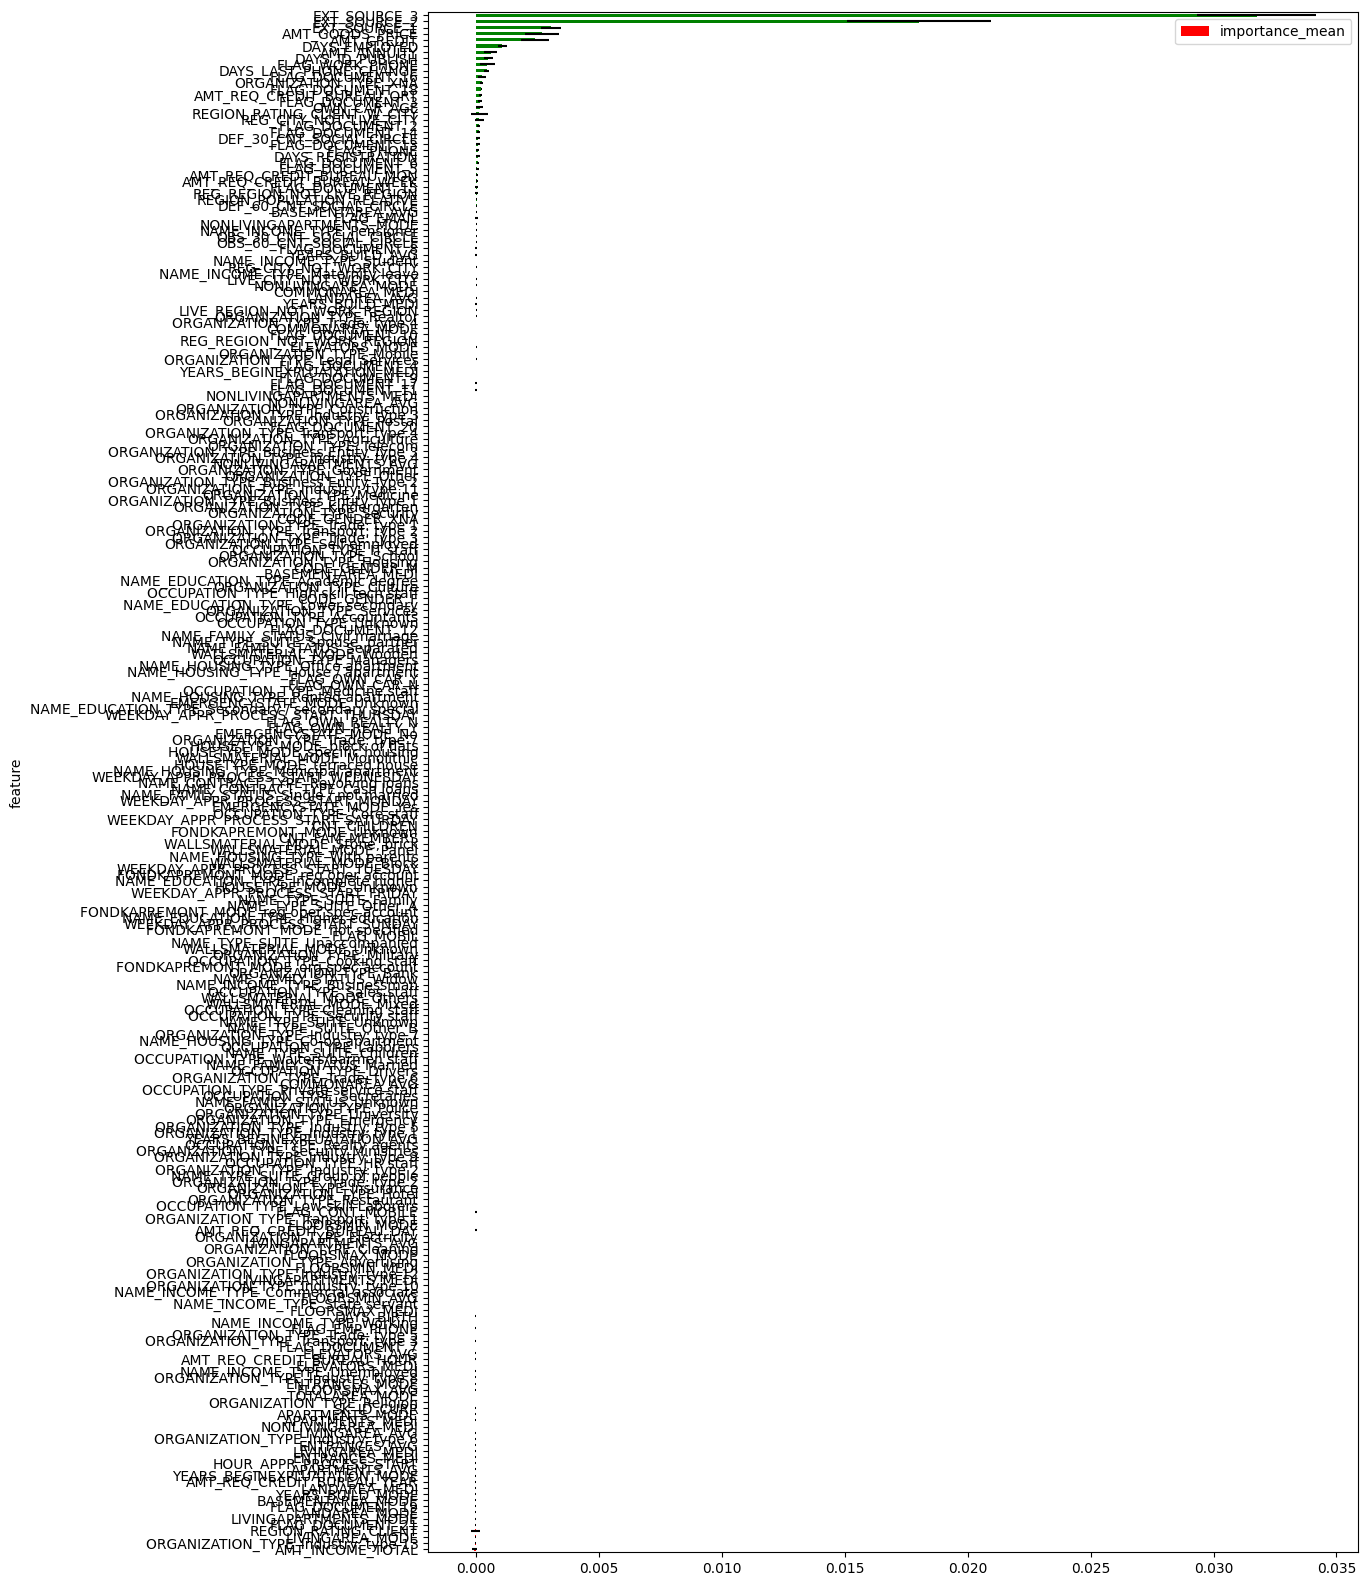

In [16]:
plot_importance(importance_df, figsize=(12, 20))

In [ ]:
selected_features = importance_df.sort_values('importance_mean', ascending=False).head(100)['feature'].tolist()